In [145]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import laplace_asymmetric

In [146]:
# Data Prep.

# Use only downs 1-4 & convert to int
train_df_encoded = df[df['down'] != 'two_point_attempt']
train_df_encoded['down'] = train_df_encoded['down'].astype(int)

# Use 'get_dummies' to convert 'pass_location' into multiple columns (left, middle, right)
# Convert categorical 'pass_location' into dummy variables
# Use drop_first=True to avoid the "dummy variable trap" (multicollinearity), drop_first=True
train_df_encoded = pd.get_dummies(train_df_encoded, columns=['pass_location', 'down'], drop_first=True)

# Remove NaNs.
train_df_encoded = train_df_encoded.dropna()

#print(train_df_encoded.dtypes)

In [147]:
# 2. Define Features (X) and Target (y)
# Multiple independent variables
X = train_df_encoded[['down_2', 
                      'down_3',
                      'down_4',
                      'goal_to_go', 
                      'ydstogo', 
                      'off_rank', 
                      'def_rank', 
                      'pass_location_middle', 
                      'pass_location_right', 
                      'shotgun', 
                      'air_yards']]
# Single dependent variable
y = train_df_encoded['yards_after_catch'] 

# 3. Initialize and train the model
model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


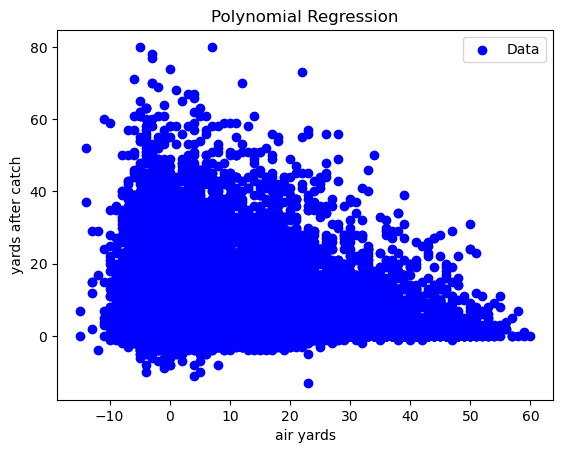

Coefficients: [-0.08449692  0.23197247 -0.19837007 -3.08159529  0.06538606 -0.01822458
  0.02242741 -0.06889333 -0.18591391 -0.76210986 -0.16885394]
Intercept: 6.021534532838086


In [148]:
plt.scatter(X['air_yards'], y, color='blue', label='Data')
#plt.plot(np.sort(X_poly, axis=0), pr.y_pred_[np.argsort(X_poly, axis=0)], color='red', label='Polynomial Fit')
plt.title("Polynomial Regression")
plt.xlabel("air yards")
plt.ylabel("yards after catch")
plt.legend()
plt.show()

# View coefficients
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")

## Getting Probabilities from the final model

In [149]:
current_model = fit_distributional_model(
    train_df=train_df_encoded,
    test_df=train_df_encoded,
    yards_col="yards_after_catch",
    features=["down_2","down_3", "down_4", 
              "off_rank","def_rank","goal_to_go",
              "ydstogo","pass_location_middle", "pass_location_right", "shotgun","air_yards"],
    dist_name="Asym. Laplace"
)


──────────────────────────────────────────────────
  Distribution    : Asym. Laplace
  Test obs        : 104,317
──────────────────────────────────────────────────
  Mean log-lik    : -2.7413
  Mean actual yds : 5.04
  Mean predicted  : 5.04
  MAE             : 4.39 yds
  Calibration 50% : 42.0%  (target 50%)
  Calibration 90% : 92.7%  (target 90%)
  KS stat (PIT)   : 0.1672  p=0.0000
  CRPS            : 2.9729  (lower is better)
──────────────────────────────────────────────────



In [192]:
def predict_yac_prob(lower, upper,
                             goal_to_go, down, ydstogo,
                             off_rank, def_rank, pass_location, shotgun,
                             air_yards, pass_completion):    

    # Manage one-hot variables
    down_2 = down_3 = down_4 = 0
    match down:
        case '2': down_2 = 1
        case '3': down_3 = 1
        case '4': down_4 = 1
    pass_location_right = pass_location_middle = 0
    match pass_location:
        case 'middle': pass_location_middle = 1
        case 'right': pass_location_right = 1

    prediction = model.predict([[
        down_2, down_3, down_4, goal_to_go, ydstogo,
        off_rank, def_rank, pass_location_middle, pass_location_right,
        shotgun, air_yards]]
    )

    # Fitted Kappa: 0.24833478978976647, Loc: -1.1478413708316806e-09, Scale: 1.3343713406042084
    # Parameters
    kappa = 0.24833478978976647
    loc = prediction
    scale = 1.3343713406042084
    
    cdf_upper = laplace_asymmetric.cdf(upper, kappa, loc, scale)
    cdf_lower = laplace_asymmetric.cdf(lower, kappa, loc, scale)

    prob = pass_completion*(cdf_upper - cdf_lower)
    
    #return float(f"{prob:.4f}")
    return np.round(prob, decimals=4)

### Test

In [151]:
p1 = predict_yac_prob(
    3, 
    100,
    goal_to_go=0, 
    down='1', 
    ydstogo=10,
    off_rank = 12,
    def_rank = 12,
    pass_location='middle', 
    shotgun=0,
    air_yards=30
)

p2 = predict_yac_prob(
    3, 
    100,
    goal_to_go=0, 
    down='1', 
    ydstogo=10,
    off_rank = 12,
    def_rank = 12,
    pass_location='middle', 
    shotgun=0,
    air_yards=10
)

print(f"version 1: {p1:.4f}")
print(f"version 2: {p2:.4f}")

version 1: 1.5913
version 2: 4.9684


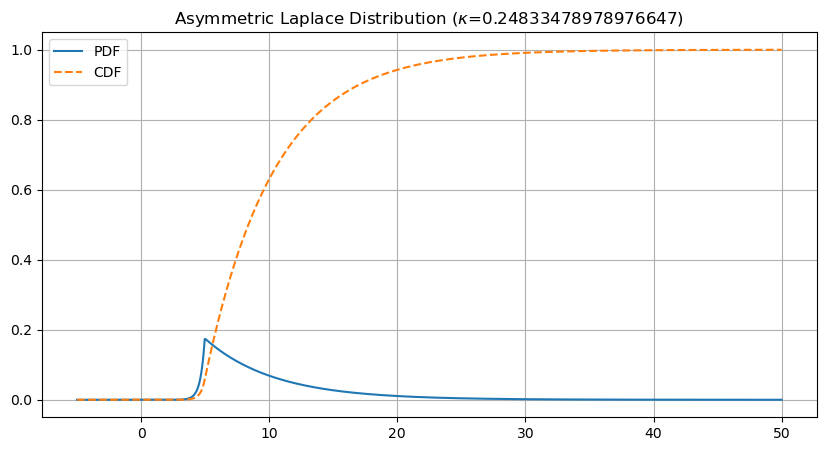

In [165]:
# Fitted Kappa: 0.24833478978976647, Loc: -1.1478413708316806e-09, Scale: 1.3343713406042084
# Parameters
kappa = 0.24833478978976647
#loc = -1.1478413708316806e-09
scale = 1.3343713406042084
#x = 2
x = np.linspace(-5, 50, 1000)

loc = 4.9684

# 1. PDF (Probability Density Function)
pdf = laplace_asymmetric.pdf(x, kappa, loc, scale)

# 2. CDF (Cumulative Distribution Function)
cdf = laplace_asymmetric.cdf(x, kappa, loc, scale)

#print(pdf)
#print(cdf)

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(x, pdf, label='PDF')
plt.plot(x, cdf, label='CDF', linestyle='--')
plt.title(f'Asymmetric Laplace Distribution ($\kappa$={kappa})')
plt.legend()
plt.grid(True)
plt.show()

In [217]:
#############################################
#                INPUTS
#############################################

down = '2'
goal_to_go   = 0
ydstogo = 5
off_rank = 12
def_rank = 12
pass_location = 'right' #Options: 'left', 'middle', 'right'
shotgun = 0
air_yards = 5
pass_completion = 0.50 # Likelihood of completed pass.  From PASS_MODEL

LOS = 48

In [218]:
#############################################
#            Getting Ranges
#############################################
ranges = ([(-1e6,-LOS)]
          +[(-LOS,-LOS+(LOS%5))]
          +[(-LOS+(LOS%5)+5*(i-1),-LOS+(LOS%5)+5*i) for i in range(1,LOS//5+1)]
          +[(-0.5,0.5)]
          +[(5*(i-1),5*i) for i in range(1,(100-LOS)//5+1)]
          +[(95+LOS%5-LOS,100-LOS)]
          +[(100-LOS,1e6)]
         )
ranges = [(c[0], c[1] - 0.5) if c[1] == 0 else c for c in ranges]
ranges = [(c[0] + 0.5, c[1]) if c[0] == 0 else c for c in ranges]
ranges = [c for c in ranges if c[0]<c[1]]
ranges = list(dict.fromkeys(ranges))
print(ranges)

[(-1000000.0, -48), (-48, -45), (-45, -40), (-40, -35), (-35, -30), (-30, -25), (-25, -20), (-20, -15), (-15, -10), (-10, -5), (-5, -0.5), (-0.5, 0.5), (0.5, 5), (5, 10), (10, 15), (15, 20), (20, 25), (25, 30), (30, 35), (35, 40), (40, 45), (45, 50), (50, 52), (52, 1000000.0)]


In [219]:
# Final output
pc_output = pd.DataFrame()
pc_output['Gain/Loss Range'] = [(0,0)]
pc_output['Yardline Range'] = [(0,0)]
pc_output['Label'] = ['Incomplete Pass']
pc_output['Probabilities'] = [1-pass_completion]
# Add the YAC data
yac_output = pd.DataFrame()
yac_output['Gain/Loss Range'] = ranges
yac_output['Yardline Range'] = [(-10,0)]+[(c[0]+LOS,c[1]+LOS) for c in ranges[1:-1]]+[(100,110)]
yac_output['Label'] = ['Safety']+[str(((['Loss of ','Gain of '][int(a>0)]+str(abs(a)),str(abs(b)))))[1:-1].replace(', ', ' to ').replace(r"'","") for a,b in ranges[1:-1]]+['Touchdown']
yac_output.loc[yac_output['Gain/Loss Range']==(-0.5,0.5),'Label'] = 'No Gain'
yac_output['Probabilities'] = yac_output['Gain/Loss Range'].apply(lambda c: predict_yac_prob(
                                                                                lower      = c[0],
                                                                                upper      = c[1],
                                                                                goal_to_go = goal_to_go,
                                                                                down = down, 
                                                                                ydstogo = ydstogo,
                                                                                off_rank = off_rank,
                                                                                def_rank = def_rank,
                                                                                pass_location=pass_location, 
                                                                                shotgun=shotgun,
                                                                                air_yards=air_yards,
                                                                                pass_completion = pass_completion)
                                                         )
print(sum(yac_output['Probabilities']))
output = pd.concat([pc_output, yac_output], ignore_index=True)

display(output)


[0.5]


,Gain/Loss Range,Yardline Range,Label,Probabilities
0,"(0, 0)","(0, 0)",Incomplete Pass,0.5
1,"(-1000000.0, -48)","(-10, 0)",Safety,[0.0]
2,"(-48, -45)","(0, 3)",Loss of 48 to 45,[0.0]
3,"(-45, -40)","(3, 8)",Loss of 45 to 40,[0.0]
4,"(-40, -35)","(8, 13)",Loss of 40 to 35,[0.0]
5,"(-35, -30)","(13, 18)",Loss of 35 to 30,[0.0]
6,"(-30, -25)","(18, 23)",Loss of 30 to 25,[0.0]
7,"(-25, -20)","(23, 28)",Loss of 25 to 20,[0.0]
8,"(-20, -15)","(28, 33)",Loss of 20 to 15,[0.0]
9,"(-15, -10)","(33, 38)",Loss of 15 to 10,[0.0]
